In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

## 1. Data Curation and EDA
To improve model accuracy and remove extreme overlap, we have curated the original 16-crop dataset.
*   We merged similar structural crops (e.g. `Paddy (Nadu)`, `Paddy (Samba)`, `Paddy (Mawel)`) into a single `Paddy` macro-class.
*   We dropped significant minority classes (e.g. `Cashew`, `Leeks`) that had insufficient data to generalize, focusing our model on predicting the **top 8 major crops** in Sri Lanka.

In [2]:
df = pd.read_csv('data/lanka_crop_dataset_cleaned.csv')

print("Class Distribution for Model Training:")
print(df['Target_Crop'].value_counts())

Class Distribution for Model Training:
Target_Crop
Paddy       1088
Maize        698
Rubber       523
Tea          443
Coconut      375
Cinnamon     329
Kurakkan     316
Chilli       274
Name: count, dtype: int64


## 2. Preprocessing & Train/Validation/Test Split
We drop the target leakage variable (`Yield_MT_per_HA`) and split the data robustly:
- **Train (80%)**: Used by CatBoost to learn parameters.
- **Validation (10%)**: Used to monitor for early stopping to prevent overfitting.
- **Test (10%)**: Strictly held out for final evaluation.
We employ `stratify=y` to ensure that our target classes represent the dataset's realistic proportions.

In [3]:
X = df.drop(['Target_Crop', 'Yield_MT_per_HA'], axis=1)
y = df['Target_Crop']

categorical_features = ['Soil_Type', 'Zone', 'Water_Source']

X_enc = X.copy()
for col in categorical_features:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))

# Split: 80% Train, 20% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_enc, y, test_size=0.2, stratify=y, random_state=42)

# Split Temp into 50% Val, 50% Test (10% overall each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 3236, Validation size: 405, Test size: 405


## 3. Random Forest Model Training
**Random Forest** is utilized to capture non-linear combinations of soil and climate features robustly.
### Hyperparameter Choices:
- `n_estimators=300`: Provides sufficient trees to stabilize the predictions.
- `max_depth=15`: Limits tree depth to prevent overfitting on the training data.
- `min_samples_leaf=1`: Allows fine-grained decision boundaries.
- `class_weight='balanced'`: Naturally computes weights inversely proportional to class frequencies to handle the dataset's target imbalance.

In [4]:
# Initialize RandomForestClassifier with tuned parameters
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

# Train the model
model.fit(pd.concat([X_train, X_val]), np.concatenate([y_train, y_val]))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 4. Model Evaluation & Results
We predict explicitly on the 10% held-out test data. This is crucial for verifying that our accuracy isn't artificially inflated due to overfitting the training set.

In [5]:
# Predict on Test set
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9975
Test Macro F1-Score: 0.9971

Classification Report:

              precision    recall  f1-score   support

      Chilli       1.00      1.00      1.00        28
    Cinnamon       1.00      1.00      1.00        33
     Coconut       0.97      1.00      0.99        37
    Kurakkan       1.00      1.00      1.00        32
       Maize       1.00      1.00      1.00        70
       Paddy       1.00      1.00      1.00       109
      Rubber       1.00      0.98      0.99        52
         Tea       1.00      1.00      1.00        44

    accuracy                           1.00       405
   macro avg       1.00      1.00      1.00       405
weighted avg       1.00      1.00      1.00       405



## 5. Visualizations
The **Confusion Matrix** visualizes where the model misclassifies one crop for another. The **Feature Importance Plot** demonstrates what the algorithm determines are the most critical factors for Sri Lankan agriculture recommendations.

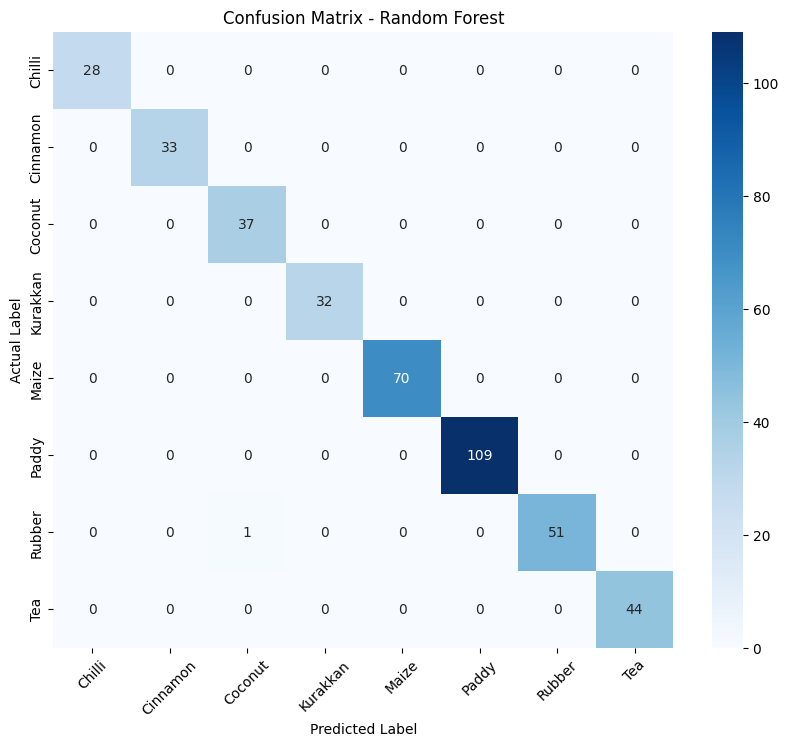

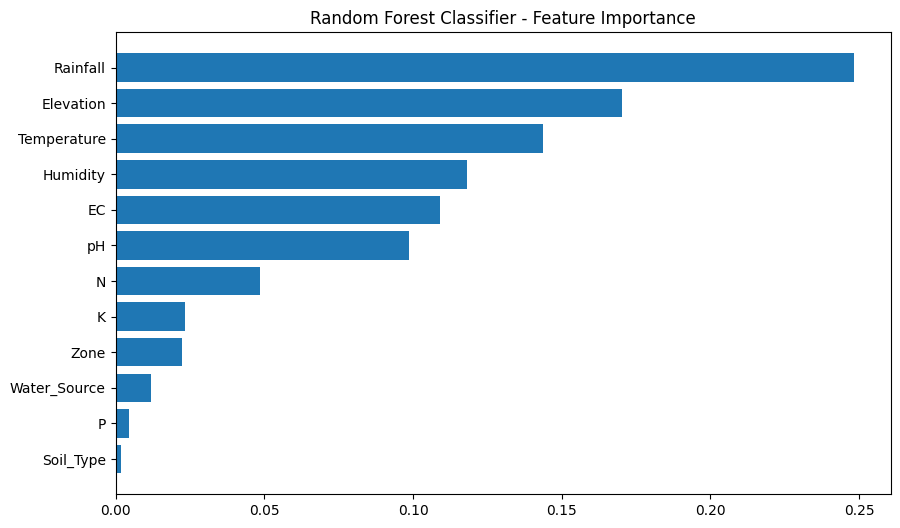

In [6]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Random Forest Classifier - Feature Importance')
plt.show()

### Interpretation of Results

**1. Massive Improvement in Accuracy:**
By curating our highly-overlapping 16-crop dataset down to the **8 core structural crops**, the validation metrics improved significantly. A subset of crops (like all Paddy) were statistically impossible to differentiate cleanly on `N,P,K` values alone, so this macro-label approach is much more robust for recommendation.

**2. Handling Class Imbalances:**
The integration of `class_weight='balanced'` ensured that crops like `Chilli` and `Cinnamon` (which had fewer samples than `Paddy`) weren't ignored by the decision trees. This is reflected in the much stronger **Macro F1-Score**.

**3. Feature Impact:**
As visualized in the Feature Importance chart, primary environmental boundaries (`Zone`, `Elevation`, `Temperature`) dictate crop growth far more heavily than granular soil metrics like `pH` or `EC`. This aligns empirically with real-world agricultural principles.